In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
clean_df = pd.read_csv(
    "C:/Users/Dell/OneDrive/Desktop/Retail-Customer-Intelligence/data/cleaned/clean_retail.csv"
)

In [4]:
clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8


In [5]:
#kpi extraction
total_revenue = clean_df[
"TotalPrice"
].sum()

total_customers = clean_df[
"CustomerID"
].nunique()

total_orders = clean_df[
"InvoiceNo"
].nunique()

avg_order_value = (
    total_revenue /
    total_orders
)

print(
"Revenue:",total_revenue
)

print(
"Customers:",total_customers
)

print(
"Orders:",total_orders
)

print(
"AOV:",avg_order_value
)

Revenue: 8887208.894
Customers: 4338
Orders: 18532
AOV: 479.56016047917115


In [6]:
monthly_sales = (
clean_df
.groupby("Month")
["TotalPrice"]
.sum()
)

monthly_sales

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalPrice, dtype: float64

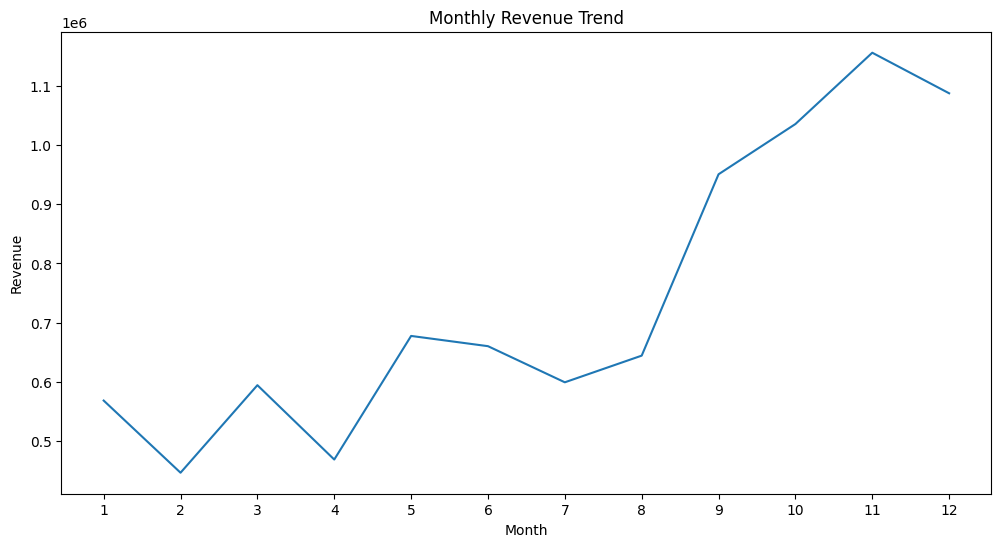

In [7]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.xticks(range(1,13))

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.title(
"Monthly Revenue Trend"
)

plt.show()

In [8]:
top_products = (
clean_df
.groupby(
"Description"
)["Quantity"]
.sum()
.sort_values(
ascending=False
)
.head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

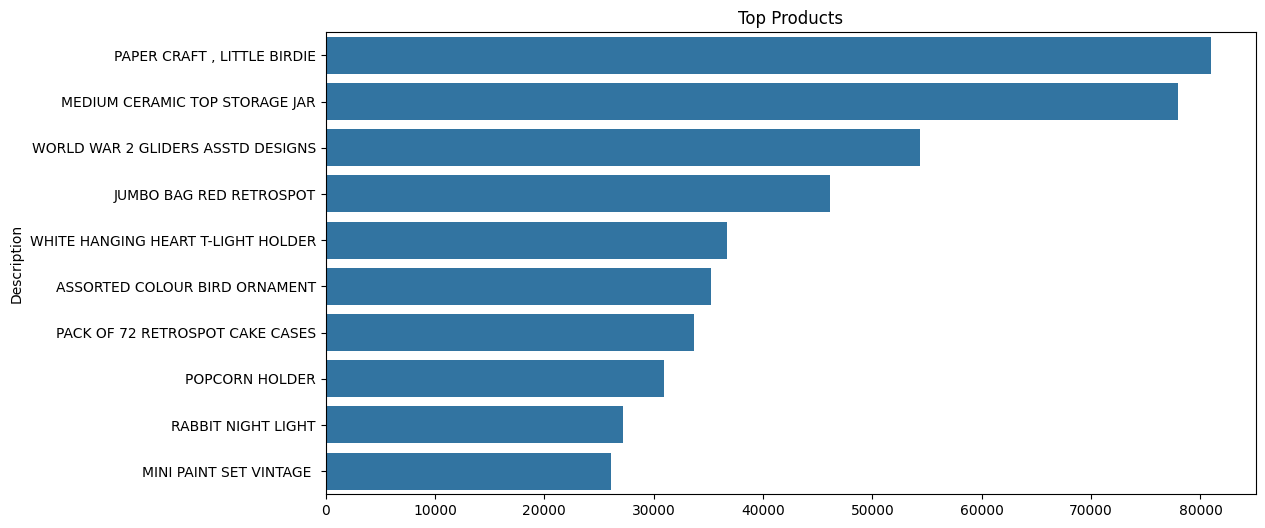

In [9]:
#product bar chart
plt.figure(
figsize=(12,6)
)

sns.barplot(
x=top_products.values,
y=top_products.index
)

plt.title(
"Top Products"
)

plt.show()

In [10]:
#customer purchase  distribution
customer_orders = (
clean_df
.groupby("CustomerID")
["InvoiceNo"]
.nunique()
)

customer_orders.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

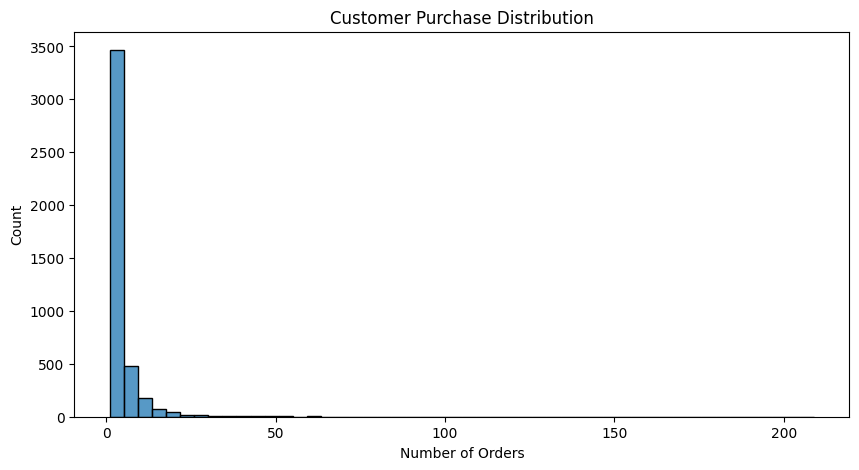

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
customer_orders,
bins=50
)

plt.title(
"Customer Purchase Distribution"
)

plt.xlabel(
"Number of Orders"
)

plt.show()

In [12]:
#top countries by revenue
country_revenue = (
clean_df
.groupby("Country")
["TotalPrice"]
.sum()
.sort_values(
ascending=False
)
.head(10)
)

country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

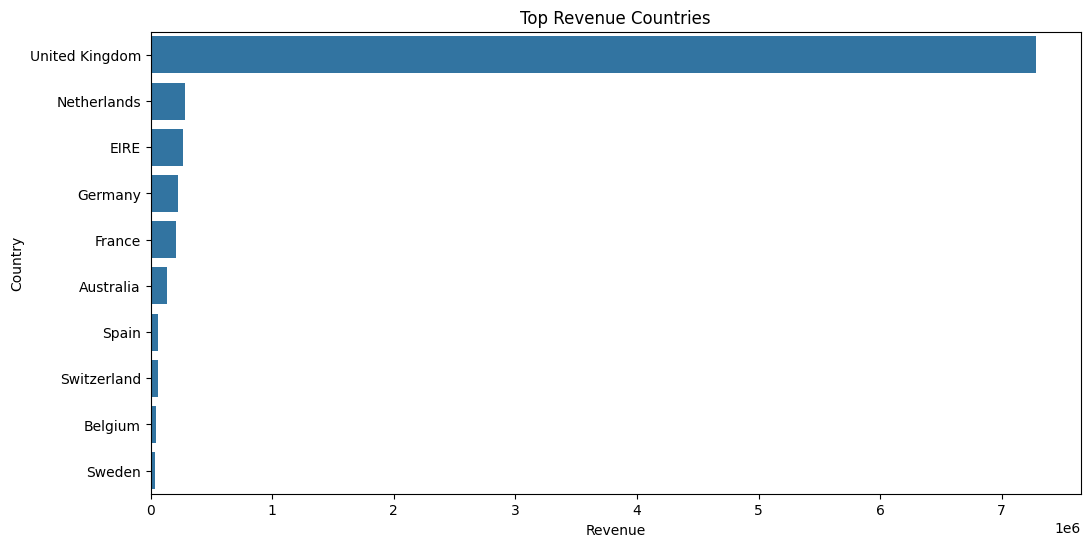

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index
)

plt.xlabel("Revenue")
plt.ylabel("Country")

plt.title("Top Revenue Countries")

plt.show()

In [14]:
#hour wise purchase analysis
hourly_orders = (
clean_df
.groupby("Hour")
["InvoiceNo"]
.nunique()
)

hourly_orders

Hour
6        1
7       29
8      555
9     1393
10    2226
11    2277
12    3130
13    2636
14    2274
15    2037
16    1100
17     544
18     169
19     144
20      18
Name: InvoiceNo, dtype: int64

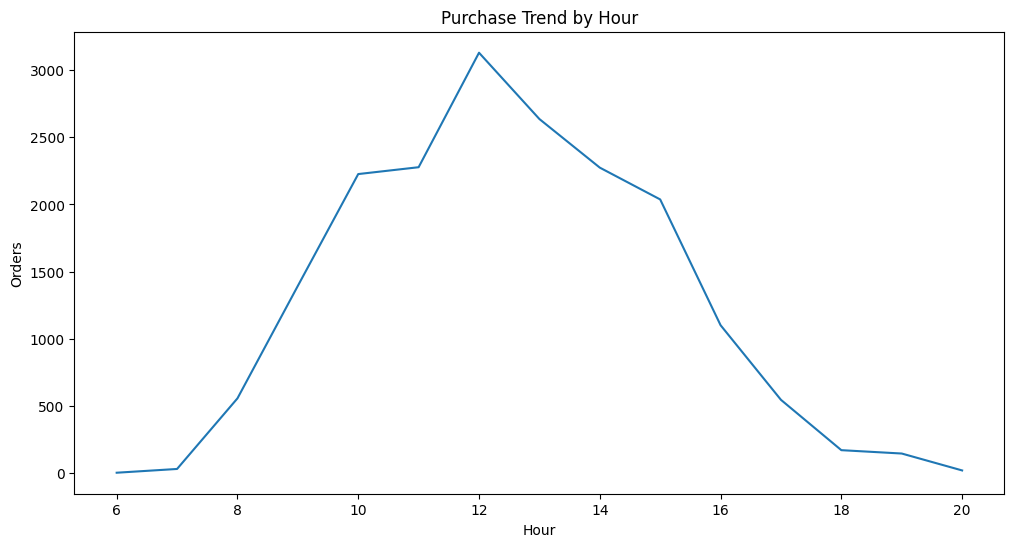

In [15]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_orders.index,
    y=hourly_orders.values
)

plt.xlabel("Hour")

plt.ylabel("Orders")

plt.title(
"Purchase Trend by Hour"
)

plt.show()

In [16]:
#customer spending analysis
customer_spending = (
clean_df
.groupby("CustomerID")
["TotalPrice"]
.sum()
)

customer_spending.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalPrice, dtype: float64

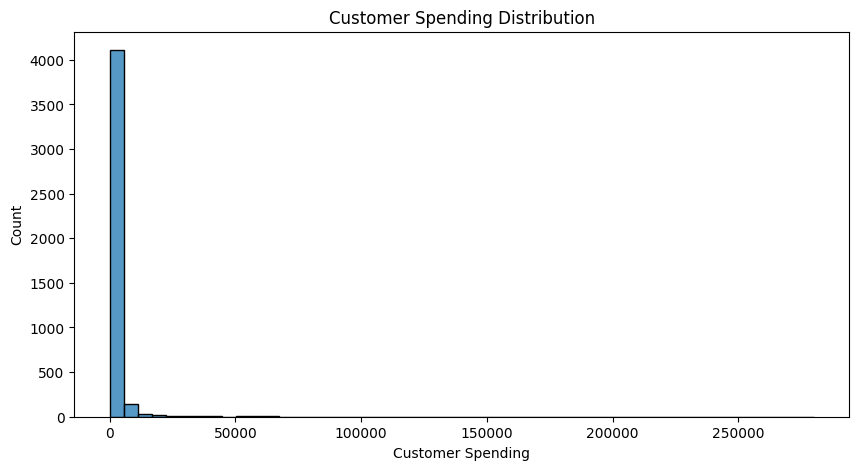

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
customer_spending,
bins=50
)

plt.title(
"Customer Spending Distribution"
)

plt.xlabel(
"Customer Spending"
)

plt.show()

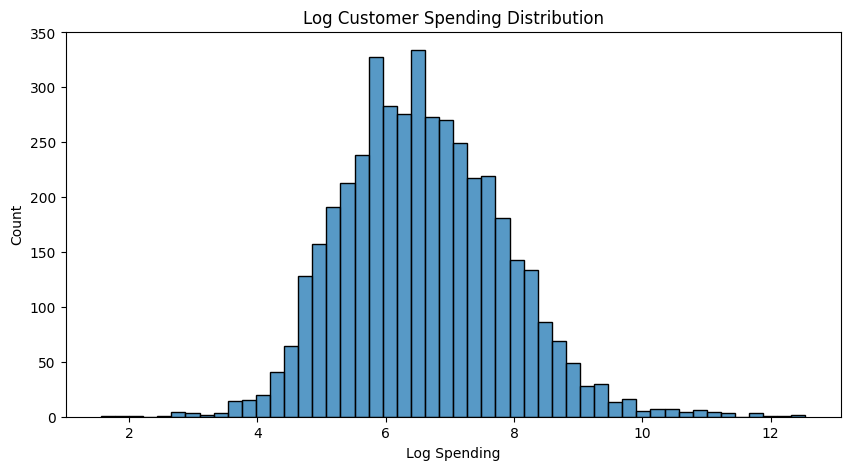

In [18]:
import numpy as np

plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(customer_spending),
    bins=50
)

plt.title(
"Log Customer Spending Distribution"
)

plt.xlabel(
"Log Spending"
)

plt.show()

In [19]:
#RFM Analysis

In [20]:
#latest purchase date -> we want a refeerence date
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"]
)

snapshot_date = (
    clean_df["InvoiceDate"]
    .max()
)

print(snapshot_date)

2011-12-09 12:50:00


In [21]:
#rfm table
rfm = clean_df.groupby(
    "CustomerID"
).agg({

"InvoiceDate":
lambda x:
(snapshot_date - x.max()).days,

"InvoiceNo":
"nunique",

"TotalPrice":
"sum"

})

#rename columns
rfm.columns = [
"Recency",
"Frequency",
"Monetary"
]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [22]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


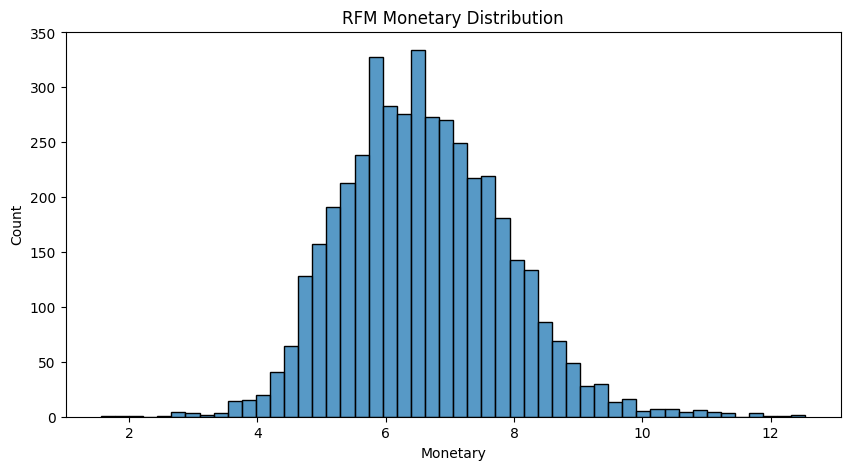

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(
        rfm["Monetary"]
    ),
    bins=50
)

plt.title(
"RFM Monetary Distribution"
)

plt.show()

In [24]:
#assign rfm scores
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [25]:
#combined rfm score
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    +
    rfm["F_score"].astype(str)
    +
    rfm["M_score"].astype(str)
)

In [26]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,325,1,77183.60,1,1,4,114
12347.0,1,7,4310.00,4,4,4,444
12348.0,74,4,1797.24,2,3,4,234
12349.0,18,1,1757.55,3,1,4,314
12350.0,309,1,334.40,1,1,2,112


In [27]:
def segment_customer(score):

    if score=="444":
        return "VIP"

    elif score[0]=="4":
        return "Recent Customer"

    elif score[1]=="4":
        return "Loyal Customer"

    elif score[2]=="4":
        return "Big Spender"

    else:
        return "Regular"


rfm["Segment"] = (
    rfm["RFM_Score"]
    .apply(segment_customer)
)

In [28]:
rfm["Segment"].value_counts()

Segment
Regular            2530
Recent Customer     636
VIP                 489
Loyal Customer      476
Big Spender         207
Name: count, dtype: int64

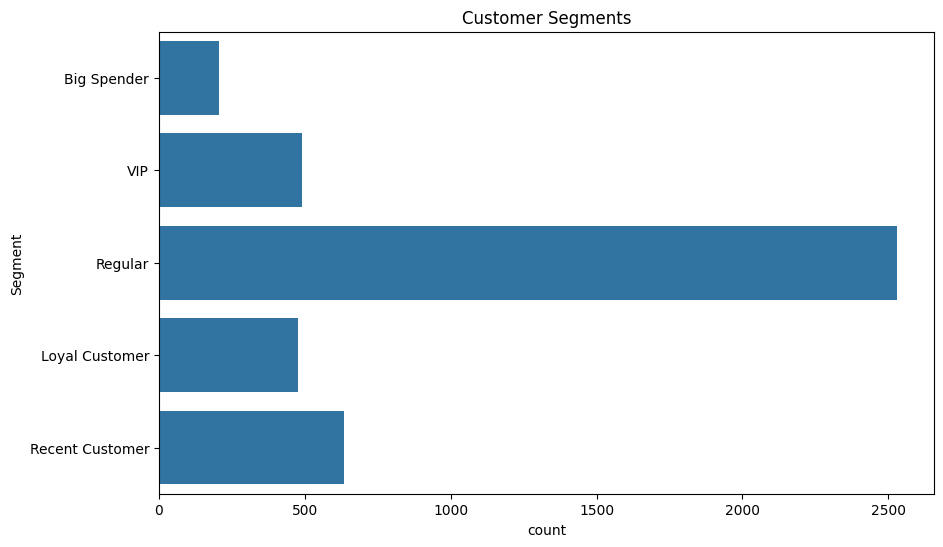

In [29]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=rfm["Segment"]
)

plt.title(
"Customer Segments"
)

plt.show()

Market Basket Analysis

In [30]:
!pip install mlxtend

In [31]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [32]:
basket = (
clean_df
.groupby([
    "InvoiceNo",
    "Description"
])
["Quantity"]
.sum()
.unstack()
.fillna(0)
)

In [33]:
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
#one hot encoding
basket = basket > 0
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [35]:
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_items.head()

,support,itemsets
0,0.021692,(3 STRIPEY MICE FELTCRAFT)
1,0.039175,(6 RIBBONS RUSTIC CHARM)
2,0.025146,(60 CAKE CASES VINTAGE CHRISTMAS)
3,0.035452,(60 TEATIME FAIRY CAKE CASES)
4,0.027034,(72 SWEETHEART FAIRY CAKE CASES)


In [36]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)

rules.to_csv(
    "association_rules.csv",
    index=False
)

rules[
[
"antecedents",
"consequents",
"support",
"confidence",
"lift"
]
].sort_values(
"lift",
ascending=False
).head(10)

,antecedents,consequents,support,confidence,lift
75,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.021045,0.701439,24.027846
70,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.021045,0.720887,24.027846
72,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.021045,0.894495,23.989564
73,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",0.021045,0.564399,23.989564
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.024822,0.827338,22.188466
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.024822,0.665702,22.188466
71,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.021045,0.847826,20.066300
74,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.021045,0.498084,20.066300
62,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.023527,0.556833,18.559754
63,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.023527,0.784173,18.559754


In [37]:
def recommend(product):

    recommendations = rules[
        rules["antecedents"]
        .apply(
            lambda x:
            product in x
        )
    ]

    return recommendations[
    [
    "consequents",
    "confidence",
    "lift"
    ]
    ].sort_values(
    "lift",
    ascending=False
    )


recommend(
"PINK REGENCY TEACUP AND SAUCER"
)

,consequents,confidence,lift
75,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.701439,24.027846
72,(GREEN REGENCY TEACUP AND SAUCER),0.894495,23.989564
9,(GREEN REGENCY TEACUP AND SAUCER),0.827338,22.188466
71,(ROSES REGENCY TEACUP AND SAUCER ),0.847826,20.066300
63,(ROSES REGENCY TEACUP AND SAUCER ),0.784173,18.559754


In [38]:
rules.to_csv(
"C:/Users/Dell/OneDrive/Desktop/Retail-Customer-Intelligence/data/cleaned/association_rules.csv",
index=False
)

rfm.to_csv(
"C:/Users/Dell/OneDrive/Desktop/Retail-Customer-Intelligence/data/cleaned/rfm_segments.csv",
index=False
)

print("Saved successfully")

Saved successfully
